# Mathematical Tools

### Exercise 1
Verify that the flow map $y(t) = \phi(t)y_{0}$, where $\phi(t) = X^{e}(t)[X^{e}(0)]^{-1}$, does solve $\dot{y} = By$. What hypotheses must the eigenvectors $v_i$ satisfy for the matrix $X^{e}(t)$ to be invertible? For what sorts of matrices B do these hypotheses always hold?

#### Answer

First part:

given 

$\dot{y} = By$

and the solution

$\phi(t) = X^{e}(t)[X^{e}(0)]^{-1}$, does solve $\dot{y} = By$

By definition, $X^{e}(t)$ is a fundamental solution matrix whose columns are individual solutions to the linear system. Therefore,

$\dot{X}^{e}(t) = BX^{e}(t)$

If you differentiate $\phi(t)$, remembering that $\phi(0) = I$, which is a constant matrix, you get:

$\dot{\phi}(t) = B\phi(t)$

Differentiating $y(t)$ yields, where $y_0$ is a constant:

$\dot{y}(t) = \dot{\phi}(t)y_{0} = B\phi(t)y_{0}$

Taking $\phi(t) = X^{e}(t)[X^{e}(0)]^{-1}$, multiply both sides by $y_0$:

$\phi(t)y_{0} = X^{e}(t)[X^{e}(0)]^{-1}y_(0)$

Matrix multiplication is associative:

$\phi(t)y_{0} = (X^{e}(t)) x ([X^{e}(0)]^{-1})(y_(0))$

$([X^{e}(0)]^{-1})(y_(0))$ is a constant. Let it be c.

$\phi(t)(y_0) = X^{e}(t)c$

By definition, any general solution to the linear system $\dot{y}(t) = By$ is a linear combination of the fundamental matrix, which is exactly written as $\phi(t)(y_0) = X^{e}(t)c$ where c is any constant.So,

$\phi(t)y_{0} = y(t)$

So,

$\dot{y}(t) = \dot{\phi}(t)y_{0} = B\phi(t)y_{0} = By(t)$

Which is what we wanted to verify.

Second part:

For the matrix to be invertible, its determinant must be non-zero. This is the same as n linearly independent eigenvectors.

Third part:

These hypotheses will hold for diagonalisable matrices:

Matrices with distinct eigenvalues

Matrices that are symmetric, i.e. $B=B^t$, due to the  real Spectral Theorem. Spectral Theorem guarantees that all eigenvalues are real, and it always possesses a full set of n mutually orthogonal eigenvectors. So, you can have repeated eigenvalues and still have linearly independent eigenvectors.

### Example 1

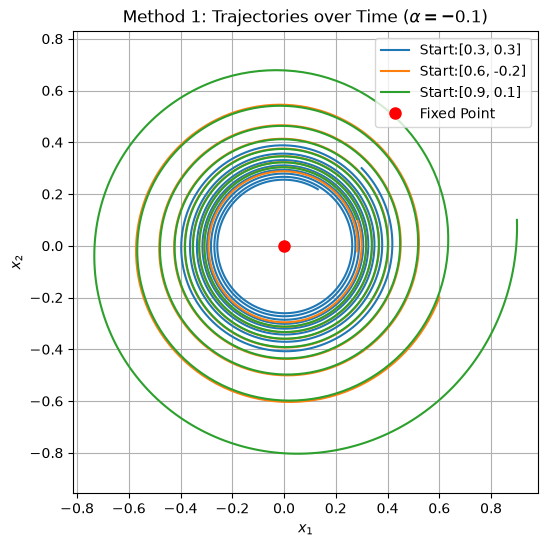

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

#The function
def degenerate_system(t, z, alpha):
    x1, x2 = z #have to package them together for solve_ivp
    r_sq = x1**2 + x2**2  # This is (x1^2 + x2^2)
    
    dx1_dt = x2 + alpha * r_sq * x1  # x2 + alpha*(x1^2 + x2^2)*x1
    dx2_dt = -x1 + alpha * r_sq * x2 # -x1 + alpha*(x1^2 + x2^2)*x2
    return [dx1_dt, dx2_dt]
    
# Setup
t_span=(0,50)
t_eval = np.linspace(0, 50, 2000)
alpha_val = -0.1 #checking negative alpha first, should be stable
initial_conditions = [[0.3,0.3], [0.6,-0.2], [0.9,0.1]]

#The plot
plt.figure(figsize=(6,6))

for ic in initial_conditions:
    sol = solve_ivp(degenerate_system, t_span, ic, args=(alpha_val,), t_eval = t_eval)
    plt.plot(sol.y[0], sol.y[1], label = f"Start:{ic}")

plt.plot(0,0, 'ro', markersize = 8, label= "Fixed Point")
plt.title(r"Method 1: Trajectories over Time ($\alpha = -0.1$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

#So this runs solve_ivp 2000 times at equal intervals for each set of initial conditions.

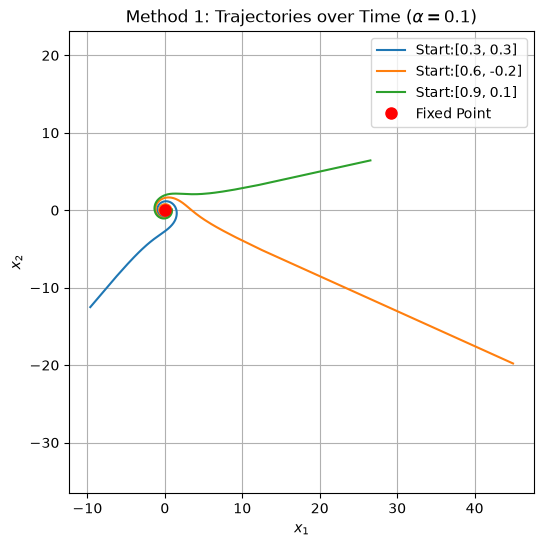

In [6]:
# Setup
t_span=(0,50)
t_eval = np.linspace(0, 50, 2000)
alpha_val = 0.1
initial_conditions = [[0.3,0.3], [0.6,-0.2], [0.9,0.1]]

#The plot
plt.figure(figsize=(6,6))

for ic in initial_conditions:
    sol = solve_ivp(degenerate_system, t_span, ic, args=(alpha_val,), t_eval = t_eval)
    plt.plot(sol.y[0], sol.y[1], label = f"Start:{ic}")

plt.plot(0,0, 'ro', markersize = 8, label= "Fixed Point")
plt.title(r"Method 1: Trajectories over Time ($\alpha = 0.1$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

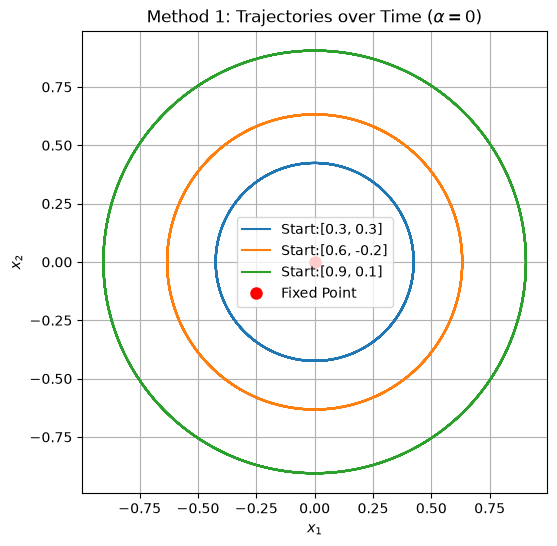

In [7]:
# Setup
t_span=(0,50)
t_eval = np.linspace(0, 50, 2000)
alpha_val = 0
initial_conditions = [[0.3,0.3], [0.6,-0.2], [0.9,0.1]]

#The plot
plt.figure(figsize=(6,6))

for ic in initial_conditions:
    sol = solve_ivp(degenerate_system, t_span, ic, args=(alpha_val,), t_eval = t_eval)
    plt.plot(sol.y[0], sol.y[1], label = f"Start:{ic}")

plt.plot(0,0, 'ro', markersize = 8, label= "Fixed Point")
plt.title(r"Method 1: Trajectories over Time ($\alpha = 0$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

So, we can see how different alphas affect the trajectory. However, this only works for specific inputs, and is inefficent. Let's see if I can get a phase plane.

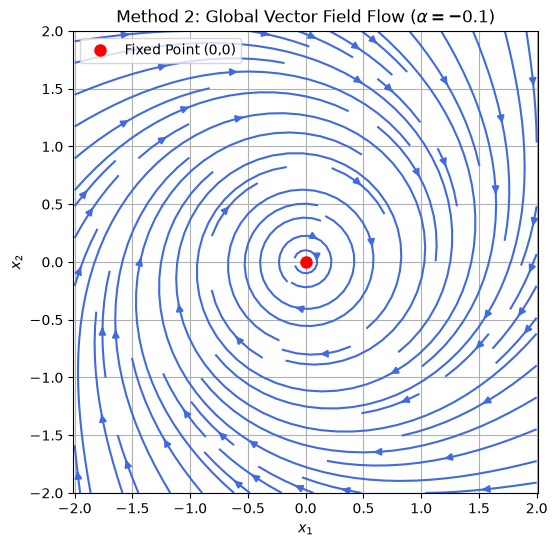

In [13]:
#Pick arbitrary values for coordinate grid
x1_vals = np.linspace(-2,2,20)
x2_vals = np.linspace(-2,2,20)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

alpha_val=-0.1
DX1, DX2 = degenerate_system(0, [X1, X2], alpha_val)

plt.figure(figsize=(6, 6))
plt.streamplot(X1, X2, DX1, DX2, color='royalblue', density=1)
plt.plot(0, 0, 'ro', markersize=8, label="Fixed Point (0,0)")

plt.title(r"Method 2: Global Vector Field Flow ($\alpha = -0.1$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

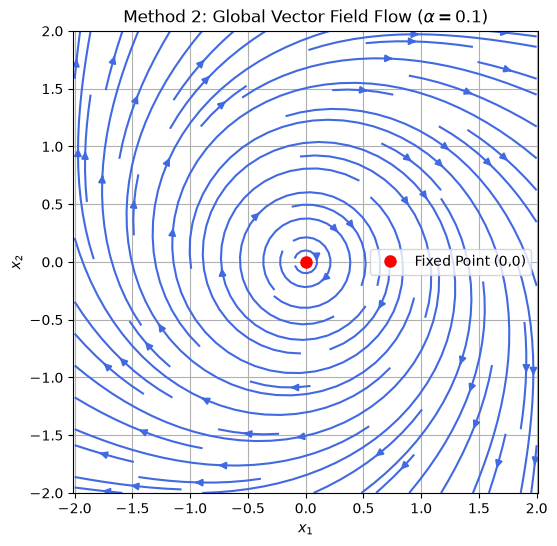

In [14]:
alpha_val=0.1
DX1, DX2 = degenerate_system(0, [X1, X2], alpha_val)

plt.figure(figsize=(6, 6))
plt.streamplot(X1, X2, DX1, DX2, color='royalblue', density=1)
plt.plot(0, 0, 'ro', markersize=8, label="Fixed Point (0,0)")

plt.title(r"Method 2: Global Vector Field Flow ($\alpha = 0.1$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

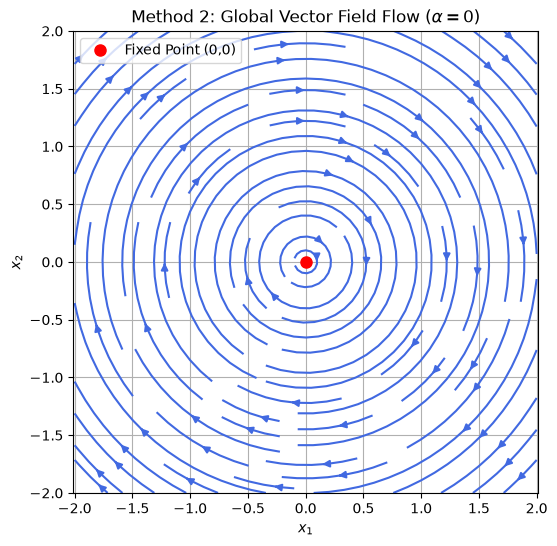

In [15]:
alpha_val=0
DX1, DX2 = degenerate_system(0, [X1, X2], alpha_val)

plt.figure(figsize=(6, 6))
plt.streamplot(X1, X2, DX1, DX2, color='royalblue', density=1)
plt.plot(0, 0, 'ro', markersize=8, label="Fixed Point (0,0)")

plt.title(r"Method 2: Global Vector Field Flow ($\alpha = 0$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

Current folder: C:\Users\User\Mathematical Neuroscience Simulations
Notebook name check skipped (library not installed).
